In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
data = pd.read_csv("Mall_Customers.csv") 
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Missing Values:\n", data.isnull().sum())

X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


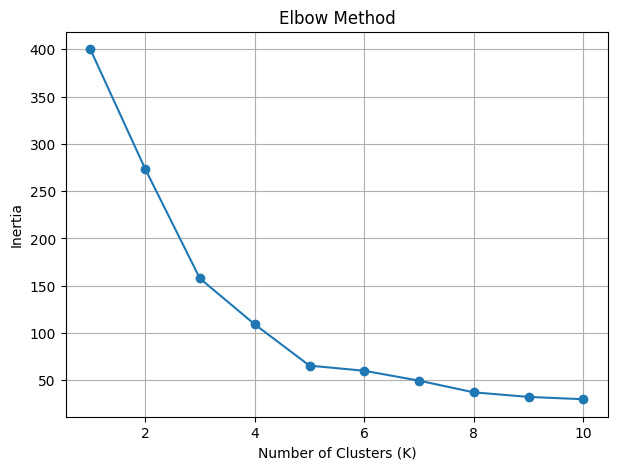

In [4]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

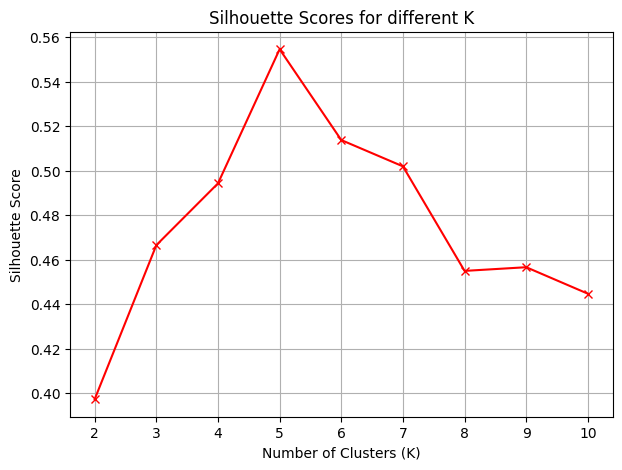

In [5]:
sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7,5))
plt.plot(range(2,11), sil_scores, marker='x', color='red')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for different K')
plt.grid(True)
plt.show()

In [6]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters
print(kmeans.cluster_centers_)
print(scaler.inverse_transform(kmeans.cluster_centers_))
data.head(10)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


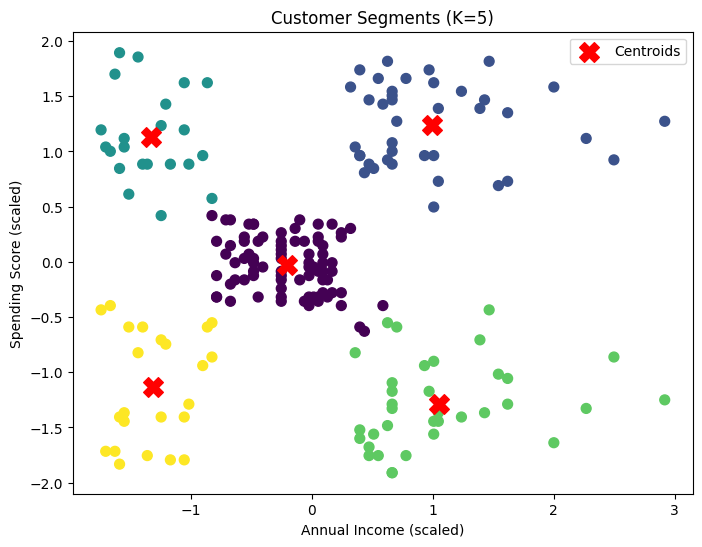

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            s=200, c='red', marker='X', label='Centroids')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title(f'Customer Segments (K={optimal_k})')
plt.legend()
plt.show()

In [8]:
print("\nCluster Counts:\n", data['Cluster'].value_counts())

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=['Annual Income', 'Spending Score'])
print("\nCluster Centroids (Original Scale):\n", centroid_df)

for i in range(optimal_k):
    cluster_data = data[data['Cluster']==i]
    print(f"\nCluster {i} Summary:")
    print("Count:", cluster_data.shape[0])
    print("Avg Income:", round(cluster_data['Annual Income (k$)'].mean(),2))
    print("Avg Spending Score:", round(cluster_data['Spending Score (1-100)'].mean(),2))


Cluster Counts:
 Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

Cluster Centroids (Original Scale):
    Annual Income  Spending Score
0      55.296296       49.518519
1      86.538462       82.128205
2      25.727273       79.363636
3      88.200000       17.114286
4      26.304348       20.913043

Cluster 0 Summary:
Count: 81
Avg Income: 55.3
Avg Spending Score: 49.52

Cluster 1 Summary:
Count: 39
Avg Income: 86.54
Avg Spending Score: 82.13

Cluster 2 Summary:
Count: 22
Avg Income: 25.73
Avg Spending Score: 79.36

Cluster 3 Summary:
Count: 35
Avg Income: 88.2
Avg Spending Score: 17.11

Cluster 4 Summary:
Count: 23
Avg Income: 26.3
Avg Spending Score: 20.91


Run 1 Cluster Labels Sample:
 [0 4 0 4 0 4 0 4 0 4] 

Run 2 Cluster Labels Sample:
 [2 4 2 4 2 4 2 4 2 4] 

Run 3 Cluster Labels Sample:
 [4 1 4 1 4 1 4 1 4 1] 

Run 4 Cluster Labels Sample:
 [2 3 2 3 2 3 2 3 2 3] 

Run 5 Cluster Labels Sample:
 [1 1 1 1 1 1 1 4 1 1] 

Number of points with consistent cluster across all 5 runs: 0/200


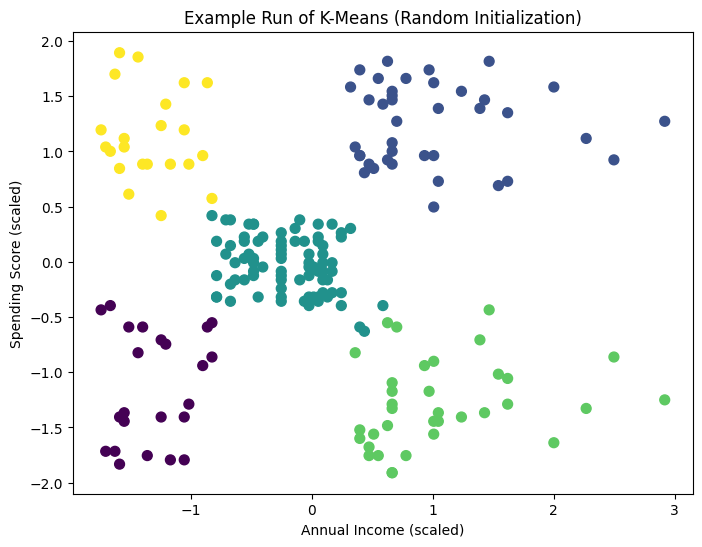

In [9]:
n_runs = 5 
cluster_results = []

for i in range(n_runs):
    kmeans_test = KMeans(n_clusters=optimal_k, n_init=1, init='random', random_state=i)
    labels = kmeans_test.fit_predict(X_scaled)
    cluster_results.append(labels)
    print(f"Run {i+1} Cluster Labels Sample:\n", labels[:10], "\n")

same_cluster_count = np.sum(np.all(np.array(cluster_results) == cluster_results[0], axis=0))
print(f"Number of points with consistent cluster across all {n_runs} runs: {same_cluster_count}/{X_scaled.shape[0]}")

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=cluster_results[0], cmap='viridis', s=50)
plt.title(f'Example Run of K-Means (Random Initialization)')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

In [10]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

print("\nK-Means Labels (first 10):", clusters[:10])
print("GMM Labels (first 10):", gmm_labels[:10])


K-Means Labels (first 10):

 [4 2 4 2 4 2 4 2 4 2]
GMM Labels (first 10): [4 2 4 2 4 2 4 2 4 2]
